In [1]:
%run functions.ipynb
# import b2plot as b2 -Was pretty lame plugin
df_chg = pd.read_pickle('DlKKs_chgMC_df.p ')
df_mix = pd.read_pickle('DlKKs_mixMC_df.p')
df_cc = pd.read_pickle('DlKKs_ccMC_df.p')
df_uds = pd.read_pickle('DlKKs_udsMC_df.p')
df_off = pd.read_pickle('DlKKs_off_df.p')
df_dat = pd.read_pickle('DlKKs_data_df.p')
#df_cmc = pd.read_pickle('DlKKs_allsim_df.p') #CMCX/allsim
df_cmc = pd.read_pickle('DlKKs_CMCX_df.p')
#---------------------------------- Data lumi = 365.290, BB cross-section = 1050000.0, Offpeak lumi = 42.740 #144643/577965 = 0.2502625591515057
df_cc2 = pd.read_pickle('old/DlKKs_ccMC_df.p')
df_chg2 = pd.read_pickle('old/DlKKs_chgMC_df.p')
df_mix2 = pd.read_pickle('old/DlKKs_mixMC_df.p')
df_dat2 = pd.read_pickle('old/DlKKs_data_df.p')
#--------------------------------- Generic MC lumi = 1461.16, wtMC = 0.250, wtMCOff = 0.029
datasmc = [df_chg,df_mix,df_cc,df_uds]
df_names = [r"$B^+B^-$", r"$B^0\bar{B}^0$", r"$c\bar{c}$", r"light $q\bar{q}$ ($u,d,s$)", r"off-resonance"]
df_namesmc = [r"$B^+B^-$", r"$B^0\bar{B}^0$", r"$c\bar{c}$", r"light $q\bar{q}$ ($u,d,s$)"]
datasmc_old = [df_chg2,df_mix2,df_cc2] #3.99 more data 
api = pdg.connect()
df_asim = df_cmc.copy() #(577965, 328) r x c initial
labbin = ['Signal','Background']
mc_weights0 = np.ndarray((577965,))
mc_weights0.fill(0.00068439) #For 1/FB
mc_weights1 = np.ndarray((577965,))
mc_weights1.fill(0.25) #standard comparison
dat_weights1 = np.ndarray((144643,))
dat_weights1.fill(0.00273755) #For 1/FB data
sig_vars = ['nROE_Ch', 'nROE_ECL', 'nROE_KL', 'Q_ROE', 'M_ROE', 'Eextra_ROE', 'R2', 'cosTBTO',
     'nROE_ECL_loose', 'M_ROE_loose', 'Eextra_ROE_loose',
     'trkK0S_ECM', 'trkK0S_pCM', 'trkK0S_InvM', 'trkK0S_cosThCM', 'trkK0S_phiCM', 'trkK0S_charge',
     'trkK0S_isSignal', 'trkK0S_isSignalAcceptMissing',
     'trk_ECM', 'trk_pCM', 'trk_InvM', 'trk_cosThCM', 'trk_phiCM', 'trk_charge',
     'trk_isSignal', 'trk_isSignalAcceptMissing', 'trk_dr', 'trk_d0Err', 'trk_dz',
     'trk_nCDCHits', 'trk_nVXDHits', 'trk_ndf', 'trk_chi2', 'trk_lastCDCLayer',
     'K0S_ECM', 'K0S_pCM', 'K0S_InvM', 'K0S_cosThCM', 'K0S_phiCM', 'K0S_charge',
     'K0S_isSignal', 'K0S_isSignalAcceptMissing', 'K0S_chiProb', 'K0S_flightDistance',
     'K0S_flightDistanceErr', 'K0S_dr', 'K0S_dz',
     'nISR', 'cosK0Strk']

tag = ['BSL_ECM', 'BSL_pCM', 'BSL_InvM', 'BSL_cosThCM', 'BSL_phiCM', 'BSL_charge',
     'BSL_BchiProb', 'BSL_BflightDistance', 'BSL_BflightDistanceErr', 'BSL_Bdr', 'BSL_Bdz',
     'BSL_isSignal', 'BSL_isSignalAcceptMissing', 'BSL_cosBY',
     'eSL_ECM', 'eSL_pCM', 'eSL_InvM', 'eSL_cosThCM', 'eSL_phiCM', 'eSL_charge',
     'eSL_isSignal', 'eSL_isSignalAcceptMissing',
     'D0SL_ECM', 'D0SL_pCM', 'D0SL_InvM', 'D0SL_cosThCM', 'D0SL_phiCM', 'D0SL_charge',
     'D0SL_DchiProb', 'D0SL_DflightDistance', 'D0SL_DflightDistanceErr',
     'D0SL_Ddr', 'D0SL_Ddz', 'D0SL_isSignal', 'D0SL_isSignalAcceptMissing',
     'cosK0SeSL', 'cosK0SD0SL']

kin_vars = ['_phiCM', '_pCM', '_ECM', '_dz', '_dr', '_cosThCM', '_InvM', '_flightDistance', '_flightDistanceErr', '_chiProb'] #10
prt_names = ['BSL','eSL','D0SL','trkK0S','trk','K0S'] #6
all_vars = [name+var for name in prt_names for var in kin_vars]

sel_funcs = [sel_mu, sel_epos,sel_pichg, sel_kchg, sel_copy]
df_asim = set_modes_sig_Bchg(df_asim)
all_modes = get_mode_dicts() # Ordered as: B+, B-, B0, Bbar0, Bs0, Bsbar0, D*+, D*-, Ds+, Ds-, D+, D-, D0, Dbar0, Tau+, Tau-
#plt.style.use("belle2")
#df_asim['signal'].isna()
#Global vars, imports, etc
#Nans only MC variables really, some minors otherwise like ID,chi2, etc
df_asim['MCtype'] = pd.NA
df_asim.loc[:258453, 'MCtype'] = 0
df_asim.loc[258454:412957, 'MCtype'] = 1
df_asim.loc[412958:549899, 'MCtype'] = 2
df_asim.loc[549900:, 'MCtype'] = 3
df_asim['label_chg'] = pd.NA
df_asim.loc[:258453, 'label_chg'] = 1
df_asim.loc[258454:412957, 'label_chg'] = 0
df_asim.loc[412958:549899, 'label_chg'] = 0
df_asim.loc[549900:, 'label_chg'] = 0
#Mc types: Chg generic is 0, mix is 1, cc is 2, uds is 3


#ex: 3 shades for chg
# paired = sns.color_palette("Paired", 9)

# charge_colors = paired[0:3]
# mix_colors = paired[3:6]
# cc_colors = paired[6:9]
# uds_colors = [paired[1], paired[4], paired[7]]
# # ex plot stkd colors
# fig, ax = plt.subplots(1,3)
# ax = ax.flatten()
# ax[0].bar([1, 2, 3], [4, 5, 6], color=uds_colors[0], label='uds')
# ax[0].bar([1, 2, 3], [3, 4, 5], color=cc_colors[0], label='cc')
# ax[0].bar([1, 2, 3], [2, 3, 4], color=mix_colors[0], label='mix')
# ax[0].bar([1, 2, 3], [1, 2, 3], color=charge_colors[0], label='chg')

# ax[1].bar([1, 2, 3], [4, 5, 6], color=uds_colors[1], label='uds')
# ax[1].bar([1, 2, 3], [3, 4, 5], color=cc_colors[1], label='cc')
# ax[1].bar([1, 2, 3], [2, 3, 4], color=mix_colors[1], label='mix')
# ax[1].bar([1, 2, 3], [1, 2, 3], color=charge_colors[1], label='chg')

# ax[2].bar([1, 2, 3], [4, 5, 6], color=uds_colors[2], label='uds')
# ax[2].bar([1, 2, 3], [3, 4, 5], color=cc_colors[2], label='cc')
# ax[2].bar([1, 2, 3], [2, 3, 4], color=mix_colors[2], label='mix')
# ax[2].bar([1, 2, 3], [1, 2, 3], color=charge_colors[2], label='chg')




# plt.legend()
# plt.show()
df_dat[:10]
#kin_vars = ['_phiCM', '_pCM', '_ECM', '_dz', '_dr', '_cosThCM', '_InvM', '_flightDistance', '_flightDistanceErr', '_chiProb'] #10
#BSL_Bdr BSL_Bdz BSL_cosBY --ECM	pCM	InvM	cosThCM	phiCM	PDG	charge	nROE_Ch	nROE_ECL	nROE_KL	Q_ROE	M_ROE	Eextra_ROE	R2	cosTBTO	nROE_ECL_loose	M_ROE_loose	Eextra_ROE_loose
#eSL_ECM	eSL_pCM	eSL_InvM	eSL_cosThCM	eSL_phiCM	eSL_PDG	eSL_charge								eSL_electronID	eSL_muonID

,__experiment__,__run__,__event__,__production__,__candidate__,__ncandidates__,__eventType__,__weight__,Ecms,aBminusMode,aBplusMode,aB0Mode,aBbar0Mode,aD0Mode,aDbar0Mode,aDplusMode,aDminusMode,ECM,pCM,InvM,cosThCM,phiCM,PDG,charge,nROE_Ch,nROE_ECL,nROE_KL,Q_ROE,M_ROE,Eextra_ROE,R2,cosTBTO,nROE_ECL_loose,M_ROE_loose,Eextra_ROE_loose,mcECM,mcPCM,mcThetaCM,mcPhiCM,isSignal,mcErrors,mcPDG,genMotherID_0,genMotherPDG_0,genMotherPDG_1,genMotherPDG_2,isSignalAcceptMissing,BSL_ECM,BSL_pCM,BSL_InvM,BSL_cosThCM,BSL_phiCM,BSL_PDG,BSL_charge,BSL_BchiProb,BSL_BflightDistance,BSL_BflightDistanceErr,BSL_Bdr,BSL_Bdz,BSL_isSignal,BSL_mcErrors,BSL_mcPDG,BSL_genMotherID_0,BSL_genMotherPDG_0,BSL_genMotherPDG_1,BSL_isSignalAcceptMissing,BSL_decayModeID,BSL_cosBY,eSL_ECM,eSL_pCM,eSL_InvM,eSL_cosThCM,eSL_phiCM,eSL_PDG,eSL_charge,eSL_isSignal,eSL_mcErrors,eSL_mcPDG,eSL_genMotherID_0,eSL_genMotherPDG_0,eSL_genMotherPDG_1,eSL_isSignalAcceptMissing,eSL_electronID,eSL_muonID,D0SL_ECM,D0SL_pCM,D0SL_InvM,D0SL_cosThCM,D0SL_phiCM,D0SL_PDG,D0SL_charge,D0SL_DchiProb,D0SL_DflightDistance,D0SL_DflightDistanceErr,D0SL_Ddr,D0SL_Ddz,D0SL_mcECM,D0SL_mcPCM,D0SL_mcThetaCM,D0SL_mcPhiCM,D0SL_isSignal,D0SL_mcErrors,D0SL_mcPDG,D0SL_genMotherID_0,D0SL_genMotherPDG_0,D0SL_genMotherPDG_1,D0SL_isSignalAcceptMissing,D0SL_decayModeID,trkK0S_ECM,trkK0S_pCM,trkK0S_InvM,trkK0S_cosThCM,trkK0S_phiCM,trkK0S_PDG,trkK0S_charge,trkK0S_isSignal,trkK0S_mcErrors,trkK0S_mcPDG,trkK0S_genMotherID_0,trkK0S_genMotherPDG_0,trkK0S_genMotherPDG_1,trkK0S_isSignalAcceptMissing,trk_ECM,trk_pCM,trk_InvM,trk_cosThCM,trk_phiCM,trk_PDG,trk_charge,trk_isSignal,trk_mcErrors,trk_mcPDG,trk_genMotherID_0,trk_genMotherPDG_0,trk_genMotherPDG_1,trk_genMotherPDG_2,trk_isSignalAcceptMissing,trk_KID,trk_piID,trk_electronID_noSVD_noTOP,trk_muonID_noSVD,trk_dr,trk_d0Err,trk_dz,trk_nCDCHits,trk_nVXDHits,trk_ndf,trk_chi2,trk_lastCDCLayer,K0S_ECM,K0S_pCM,K0S_InvM,K0S_cosThCM,K0S_phiCM,K0S_PDG,K0S_charge,K0S_isSignal,K0S_mcErrors,K0S_mcPDG,K0S_genMotherID_0,K0S_genMotherPDG_0,K0S_genMotherPDG_1,K0S_genMotherPDG_2,K0S_isSignalAcceptMissing,K0S_chiProb,K0S_flightDistance,K0S_flightDistanceErr,K0S_dr,K0S_dz,pi1_ECM,pi1_pCM,pi1_InvM,pi1_cosThCM,pi1_phiCM,pi1_PDG,pi1_charge,pi1_isSignal,pi1_mcErrors,pi1_mcPDG,pi1_genMotherID_0,pi1_genMotherPDG_0,pi1_genMotherPDG_1,pi1_genMotherPDG_2,pi1_isSignalAcceptMissing,pi1_KID,pi1_piID,pi1_electronID_noSVD_noTOP,pi1_muonID_noSVD,pi1_dr,pi1_d0Err,pi1_dz,pi1_nCDCHits,pi1_nVXDHits,pi1_ndf,pi1_chi2,pi1_lastCDCLayer,pi2_ECM,pi2_pCM,pi2_InvM,pi2_cosThCM,pi2_phiCM,pi2_PDG,pi2_charge,pi2_isSignal,pi2_mcErrors,pi2_mcPDG,pi2_genMotherID_0,pi2_genMotherPDG_0,pi2_genMotherPDG_1,pi2_genMotherPDG_2,pi2_isSignalAcceptMissing,pi2_KID,pi2_piID,pi2_electronID_noSVD_noTOP,pi2_muonID_noSVD,pi2_dr,pi2_d0Err,pi2_dz,pi2_nCDCHits,pi2_nVXDHits,pi2_ndf,pi2_chi2,pi2_lastCDCLayer,nMCGen,MCGenPDG_0,MCGenMothIndex_0,MCGenPDG_1,MCGenMothIndex_1,MCGenPDG_2,MCGenMothIndex_2,MCGenPDG_3,MCGenMothIndex_3,MCGenPDG_4,MCGenMothIndex_4,MCGenPDG_5,MCGenMothIndex_5,MCGenPDG_6,MCGenMothIndex_6,MCGenPDG_7,MCGenMothIndex_7,MCGenPDG_8,MCGenMothIndex_8,MCGenPDG_9,MCGenMothIndex_9,MCGenPDG_10,MCGenMothIndex_10,MCGenPDG_11,MCGenMothIndex_11,MCGenPDG_12,MCGenMothIndex_12,MCGenPDG_13,MCGenMothIndex_13,MCGenPDG_14,MCGenMothIndex_14,MCGenPDG_15,MCGenMothIndex_15,MCGenPDG_16,MCGenMothIndex_16,MCGenPDG_17,MCGenMothIndex_17,MCGenPDG_18,MCGenMothIndex_18,MCGenPDG_19,MCGenMothIndex_19,MCGenPDG_20,MCGenMothIndex_20,MCGenPDG_21,MCGenMothIndex_21,MCGenPDG_22,MCGenMothIndex_22,MCGenPDG_23,MCGenMothIndex_23,MCGenPDG_24,MCGenMothIndex_24,MCGenPDG_25,MCGenMothIndex_25,MCGenPDG_26,MCGenMothIndex_26,MCGenPDG_27,MCGenMothIndex_27,MCGenPDG_28,MCGenMothIndex_28,MCGenPDG_29,MCGenMothIndex_29,MCGenPDG_30,MCGenMothIndex_30,MCGenPDG_31,MCGenMothIndex_31,MCGenPDG_32,MCGenMothIndex_32,MCGenPDG_33,MCGenMothIndex_33,MCGenPDG_34,MCGenMothIndex_34,MCGenPDG_35,MCGenMothIndex_35,MCGenPDG_36,MCGenMothIndex_36,MCGenPDG_37,MCGenMothIndex_37,MCGenPDG_38,MCGenMothIndex_38,

In [2]:


#def assign_gentype(df):
    
    
"""NROE_Ch == 0  
Extra_ROE < 0.93  
Extra_ROE_Loose < 1.84  
M_ROE_Loose < 6.58  
M_ROE < 4  
BSL_BchiProb > 1e-8  
(BSL_COSBY >= -3) & (BSL_COSBY <= 1.1)  
(ESL_PCM < 2.5) & (trk_PCM < 2.5) & (K0S_PCM < 2.5)  
(K0S_InvM >= 0.4885) & (K0S_InvM <= 0.5065)  
K0S_flightDistance > 1  
K0S_flightDistanceErr > 0.5


NROE_Ch == 0  
Extra_ROE < 0.93  
# Extra_ROE_Loose < 1.84  
# M_ROE_Loose < 6.58  
# M_ROE < 4  
BSL_BchiProb > 1e-8  
(BSL_COSBY >= -3) & (BSL_COSBY <= 1.1)  
(ESL_PCM < 2.5) & (trk_PCM < 2.5) & (K0S_PCM < 2.5)  
(K0S_InvM >= 0.4885) & (K0S_InvM <= 0.5065)  
# K0S_flightDistance > 1  
# K0S_flightDistanceErr > 0.5

NROE_Ch == 0  
Extra_ROE < 0.93  
Extra_ROE_Loose < 1.84  
M_ROE_Loose < 6.58  
M_ROE < 4  
BSL_BchiProb > 1e-8  
(BSL_COSBY >= -3) & (BSL_COSBY <= 1.1)  
(ESL_PCM < 2.5) & (trk_PCM < 2.5) & (K0S_PCM < 2.5)  
(K0S_InvM >= 0.4885) & (K0S_InvM <= 0.5065)  
# K0S_flightDistance > 1  
# K0S_flightDistanceErr > 0.5


NROE_Ch == 0  
Extra_ROE < 0.93  
Extra_ROE_Loose < 1.84  
M_ROE_Loose < 6.58  
M_ROE < 4  
BSL_BchiProb > 1e-8  
(BSL_COSBY >= -3) & (BSL_COSBY <= 1.1)  
(ESL_PCM < 2.5) & (trk_PCM < 2.5) & (K0S_PCM < 2.5)  
(K0S_InvM >= 0.4885) & (K0S_InvM <= 0.5065)  
K0S_flightDistance > 1  
K0S_flightDistanceErr > 0.5
"""

# plt.subplot()
# sims = [[sel(df) for df in datasmc] for sel in sel_funcs]
# dats = [sel(df_dat) for sel in sel_funcs]
# sim_vals = [sim['K0S_InvM'] for sim in sims[0]]
# dat_vals = dats[0]['K0S_InvM']
# bins = np.arange(0.4,0.6,0.01)
# weights = np.full_like(dat_vals, 4)
# counts, bins = np.histogram(dat_vals, bins=bins, weights=weights)
# plt.hist(sim_vals,bins=bins,stacked=True)
# plt.hist(dat_vals,bins=bins,histtype='step',weights=weights)
# df_asim.query('signal < 99')['signal'].value_counts() # none above 99, below 1001. None that are 99 and not errors was all checked

# 3.0     11188
# 4.0      8342
# 5.0      4011
# 6.0      1571
# 7.0       535
# 8.0       171
# 2.0       119
# 9.0        46
# 10.0       21
df_asim[:12]  #reference data
# overviews = [ovw[1] for ovw in ovw_decom_chgs] #maybe do overviews where k0s is signal is 1
# for ent in sel_mc1_trks:
#     print(len(ent)) #5 sels, then 4 track types. Now plot each 4 track type and its combined
# #So plot every 5
# print('space\n\n')
# for ent in sel_dat1_trks:
#     print(len(ent))
# Sanity check confirmed old plots had to be wrong
#Consider boosting and scaling both vals, vars, and plots 

(df_asim['__ncandidates__'].value_counts().values/np.array(df_asim['__ncandidates__'].value_counts().keys())).astype(int)

x = [348808,
 75503,
 11303,
 6458,
 1059,
 1171,
 285,
 213,
 80,
 58,
 29,
 14,
 8,
 6,
 8,
 6,
 2,
 1,
 2,
 1,
 1]
# 300665 event, sum of 445016 candidates, 577965 total
#300665 unique events in all data stacked. Ah, issue I bet some chg and mix etc share event number, different candidates
(np.array(x)/577965*100).astype(float)

array([6.03510593e+01, 1.30635938e+01, 1.95565475e+00, 1.11736870e+00,
       1.83229088e-01, 2.02607424e-01, 4.93109444e-02, 3.68534427e-02,
       1.38416686e-02, 1.00352097e-02, 5.01760487e-03, 2.42229201e-03,
       1.38416686e-03, 1.03812515e-03, 1.38416686e-03, 1.03812515e-03,
       3.46041715e-04, 1.73020858e-04, 3.46041715e-04, 1.73020858e-04,
       1.73020858e-04])

In [3]:
no_d_chg = df_chg.query('(aD0Mode == -99) & (aDbar0Mode == -99) & (aDplusMode == -99) & (aDminusMode == -99)')

In [4]:
# sel1, sel2, sel3, sel4 = initial_sel1(df_asim),initial_sel2(df_asim), initial_sel3(df_asim), initial_sel4(df_asim)
# dat1, dat2, dat3, dat4 = initial_sel1(df_dat),initial_sel2(df_dat), initial_sel3(df_dat), initial_sel4(df_dat)
# sel_mc1 = [df_asim, sel1,sel2,sel3,sel4]
# sel_dat1 = [df_dat, dat1,dat2,dat3,dat4]
# sel_mc1_trks = [func(df) for df in sel_mc1 for func in sel_funcs] #again k0s is signal or something, maybe for plots \\ also, sel->trksel->df 16, --Mu,e,pi,k,N/A
# sel_dat1_trks = [func(df) for df in sel_dat1 for func in sel_funcs] 
# sel_mc1_chgs = [df.query('MCtype == 0') for df in sel_mc1_trks] #again k0s is signal or something, maybe for decay modes?
# ovw_decom_chgs = [get_modes_sig_Bchg(df) for df in sel_mc1_chgs]

In [5]:
# ovc_lis_nochg = get_modes_sig_Bchg2(sel_no_chgtrks(df_chg)) #maybe call it sel_no_chgtrks?
# ovc_lis_nochg = ovc_lis_nochg[1:]
# filepath1 = 'nochgtrk/'
# particles = [{'particle': ['K0S_InvM', ["#ff9999","#66b3ff","#99ff99","#ffcc99"], rf'M(K^0_S)', 0.48,0.51,20]}, {'particle': ['K0S_pCM', ["#ff9999","#66b3ff","#99ff99","#ffcc99"], rf'qCM(K^0_S)',0.48,0.51,20]},
#              {'particle': ['trk_InvM', ["#ff9999","#66b3ff","#99ff99","#ffcc99"], rf'M(e^\pm,\mu^\pm,\pi^\pm,K^\pm)',0,10,50]},{'particle': ['Eextra_ROE', ["#ff9999","#66b3ff","#99ff99","#ffcc99"],
#                                                                                                                                      rf'E_{{\mathrm{{extra}}}}^{{\mathrm{{ROE}}}}',0,2,20]}]
# df_asim_nochg = sel_no_chgtrks(df_asim)
# datasmc_nochg = [sel_no_chgtrks(df) for df in datasmc]
# dat_nochg = sel_no_chgtrks(df_dat)



In [6]:
# for df, gentype in zip([*datasmc_nochg, dat_nochg], ['chg','mix','cc','uds', 'dat']):
#     print(gentype)
#     v = ((df['__ncandidates__'].value_counts().values/np.array(df['__ncandidates__'].value_counts().keys())).astype(int))/len(df)*100
#     for c in v:
#         print(f"{c:.3f}")
    

#     print(df['trk_PDG'].value_counts())
# plot_full_ovc_summary(ovc_lis_nochg, df_asim_nochg, all_modes,filepath1, count=20)
# for particle in particles:
#     plot_by_trk(datasmc_nochg,dat_nochg,particle,filepath=filepath1)
    

In [7]:
# ovc_lis = get_modes_sig_Bchg2(df_chg)
# ovc_lis = ovc_lis[1:]
# ovc_lis2 = get_modes_sig_Bchg2(selec_1(df_chg))
# ovc_lis2 = ovc_lis2[1:]
# particle = 'B/'
# key = '_InvM'
# key_d = {'particle': ['trkK0S_pCM', ["#ff9999","#66b3ff","#99ff99","#ffcc99"], rf'pCM(B_{{signal}})', 0,5,20]} #Need 9 diverging colormaps
# #'particle': ['var name', [colors], x label rf string, min, max, bin count... Adjust to list of bins?]

In [8]:
# #plot_full_ovc_summary(ovc_lis, df_asim, all_modes,f"{particle}", count=20)
# #plot_full_ovc_summary(ovc_lis2, selec_1(df_asim), all_modes,f"{particle}", count=20)
# plot_by_trk(datasmc,df_dat,selec_1,key_d,filepath=f"{particle}")


In [9]:
# datamcsel1 = [initial_sel1(df) for df in datasmc]
# dat2 = initial_sel1(df_dat)
# plot_by_trk(datamcsel1,dat2,'K0S_InvM')

In [10]:
# datamcsel2 = [initial_sel2(df) for df in datasmc]
# dat3 = initial_sel2(df_dat)
# plot_by_trk2(datamcsel2,dat3,'K0S_InvM')

Unique labels in y_test: [0 1]
y_test dtype: int64


C:\Users\Thomas\belle2-analysis\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:07:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test ROC AUC: 0.7763


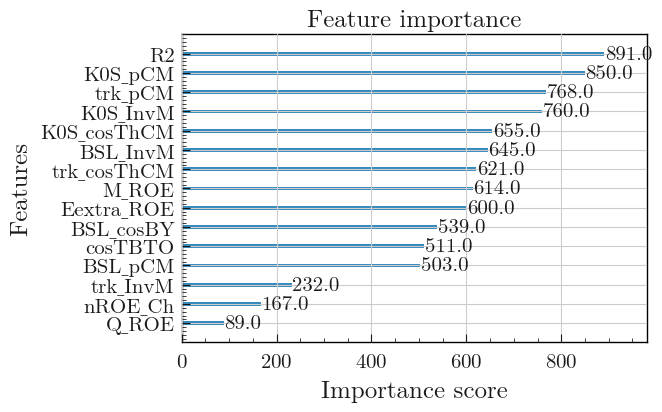

<Figure size 600x400 with 0 Axes>

In [11]:

features_ini = [
    'nROE_Ch', 'Q_ROE', 'M_ROE', 'Eextra_ROE', 'R2', 'cosTBTO',
    'K0S_InvM', 'K0S_pCM', 'K0S_cosThCM',
    'trk_InvM', 'trk_pCM', 'trk_cosThCM',
    'BSL_cosBY', 'BSL_pCM', 'BSL_InvM'
]

X = df_asim[features_ini].fillna(-999)
y = df_asim['label_chg']

le = LabelEncoder()
y_enc = le.fit_transform(y)  

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.3, stratify=y_enc, random_state=42
)

print("Unique labels in y_test:", np.unique(y_test))
print("y_test dtype:", y_test.dtype)

sample_weight_train = np.full(len(y_train), 0.25)
sample_weight_test = np.full(len(y_test), 0.25)

clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.2,
    eval_metric='auc',
    use_label_encoder=False
)

clf.fit(X_train, y_train, sample_weight=sample_weight_train)

y_pred_proba = clf.predict_proba(X_test)[:, 1]

print(f"Test ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

xgb.plot_importance(clf, max_num_features=20)
plt.show()
plt.savefig('Neural1.pdf',format='pdf')
selected = clf.predict_proba(X)[:, 1] > 0.5

df_selected = df_asim[selected]
